In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os

## Image Classification using ResNet-18 Pretrained model

In [2]:
"""
Data Transformations for Image Preprocessing (Training & Validation)

This dictionary defines the preprocessing steps applied to images before
they are fed into a deep learning model (e.g., ResNet).

Why do we need transformations?
-------------------------------
Neural networks do not take raw images directly. Images must be:
1. Resized to a consistent shape
2. Converted to tensors (numerical format)
3. Normalized for stable and faster training
4. Augmented (for training data) to improve generalization

Structure:
----------
data_transforms = {
    'train': <transformations applied during training>,
    'val'  : <transformations applied during validation/testing>
}

------------------------------------------------------------
TRAIN TRANSFORMS (data_transforms['train'])
------------------------------------------------------------
These transformations include *data augmentation* to help the model
learn robust features and avoid overfitting.

1. RandomResizedCrop(224)
   - Randomly crops a portion of the image and resizes it to 224x224.
   - Introduces variation in scale and viewpoint.
   - Required because ResNet expects input size = 224x224.

2. RandomHorizontalFlip()
   - Randomly flips the image horizontally (left ↔ right).
   - Helps the model learn that orientation does not change the class.

3. ToTensor()
   - Converts PIL Image or NumPy array → PyTorch Tensor.
   - Changes pixel range from [0, 255] → [0, 1].

4. Normalize(mean, std)
   - Standardizes pixel values using:
       output = (input - mean) / std
   - Mean = [0.485, 0.456, 0.406]
   - Std  = [0.229, 0.224, 0.225]
   - These values are from ImageNet dataset (used to pretrain ResNet).
   - Ensures compatibility with pretrained models.

------------------------------------------------------------
VALIDATION TRANSFORMS (data_transforms['val'])
------------------------------------------------------------
These transformations do NOT include randomness.
We want consistent and reproducible evaluation.

1. Resize(256)
   - Resizes the smaller edge of the image to 256 pixels.

2. CenterCrop(224)
   - Crops the center 224x224 region.
   - Ensures consistent input size.

3. ToTensor()
   - Converts image to tensor format.

4. Normalize(mean, std)
   - Same normalization as training data.

------------------------------------------------------------
KEY DIFFERENCE: TRAIN vs VALIDATION
------------------------------------------------------------
Train:
   - Includes randomness (augmentation)
   - Helps model generalize better

Validation:
   - Deterministic (no randomness)
   - Ensures fair and stable evaluation

------------------------------------------------------------
FINAL OUTPUT:
------------------------------------------------------------
Each transformation pipeline outputs a normalized tensor of shape:
    (3, 224, 224)
where:
    3 = RGB channels
    224x224 = image size expected by ResNet
"""

# Define data transformations for data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),  # ResNet expects 224 x 224 input images
        transforms.RandomHorizontalFlip(),  # Randomly flip images for augmentation
        transforms.ToTensor(),              # Convert image to PyTorch tensor
        transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                             [0.229, 0.224, 0.225])  # ImageNet std
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),             # Resize shorter side to 256
        transforms.CenterCrop(224),         # Crop center 224 x 224
        transforms.ToTensor(),              # Convert to tensor
        transforms.Normalize([0.485, 0.456, 0.406],  # Same normalization as training
                             [0.229, 0.224, 0.225])
    ]),
}

## Creating the data loaders

In [3]:
# Define the data directory
data_dir = 'dataset'

# Create data loaders
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),data_transforms[x]) for x in ['train', 'val']}


In [4]:
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(dataset_sizes)

class_names = image_datasets['train'].classes
class_names



{'train': 380, 'val': 364}


['daisy', 'dandelion']

## Transfer Learning using Pretrained ResNet-18

In [5]:
"""
Transfer Learning using Pretrained ResNet-18

This code demonstrates how to use a pretrained ResNet-18 model
and fine-tune it for a new classification task.

------------------------------------------------------------
WHAT IS HAPPENING HERE?
------------------------------------------------------------
Instead of training a deep neural network from scratch (which requires
large data and time), we use a pretrained model trained on ImageNet.

This approach is called:
👉 Transfer Learning

The idea:
- Early layers learn general features (edges, textures)
- Final layers learn task-specific features (e.g., cats vs dogs)

We reuse learned knowledge and only retrain the final layer.

------------------------------------------------------------
STEP 1: LOAD PRETRAINED MODEL
------------------------------------------------------------
model = models.resnet18(pretrained=True)

- Loads ResNet-18 architecture with pretrained weights (ImageNet).
- The model already knows useful visual features.
- Saves training time and improves performance.

------------------------------------------------------------
STEP 2: FREEZE ALL LAYERS EXCEPT FINAL LAYER
------------------------------------------------------------
for name, param in model.named_parameters():
    if "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Explanation:
- "fc" = fully connected layer (final classification layer)
- We ONLY train this layer for our new task.

Why freeze layers?
- Prevents changing pretrained knowledge
- Reduces computation
- Avoids overfitting on small datasets

Result:
- Frozen layers → act as feature extractor
- Final layer → learns your dataset

------------------------------------------------------------
STEP 3: DEFINE LOSS FUNCTION
------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

- Used for multi-class classification problems
- Combines:
    - Softmax activation
    - Log loss
- Expected inputs:
    - Model outputs (logits)
    - Ground truth labels

------------------------------------------------------------
STEP 4: DEFINE OPTIMIZER
------------------------------------------------------------
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

- SGD = Stochastic Gradient Descent
- Updates model weights during training

Parameters:
- lr (learning rate):
    Controls how big the update step is
    (Too high → unstable, Too low → slow learning)

- momentum:
    Helps accelerate learning and reduce oscillation

NOTE:
Even though all parameters are passed:
- Only layers with requires_grad=True will be updated

------------------------------------------------------------
STEP 5: MOVE MODEL TO DEVICE (GPU/CPU)
------------------------------------------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

- Checks if GPU is available
- Moves model to GPU for faster computation
- If GPU not available → uses CPU

------------------------------------------------------------
FINAL SUMMARY
------------------------------------------------------------
✔ Pretrained model loaded
✔ Most layers frozen (feature extractor)
✔ Final layer trained for new task
✔ Loss + optimizer defined
✔ Model moved to GPU if available

This is the most common and efficient way to train deep models
on small or medium-sized datasets.
"""

# Load the pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all layers except the final classification layer
for name, param in model.named_parameters():
    if "fc" in name:  # Unfreeze the final classification layer
        param.requires_grad = True  # update weights during training
    else:
        param.requires_grad = False

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Move the model to the GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

c:\Users\subin\OneDrive\Desktop\AI COURSE\COMPUTER_VISION\cnn\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\subin\OneDrive\Desktop\AI COURSE\COMPUTER_VISION\cnn\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training the ResNet-18 Pretrained model using PyTorch

In [6]:
"""
PyTorch Training & Validation Loop (Step-by-Step Explanation)

This code performs the full training process of a deep learning model,
including both training and validation phases for multiple epochs.

------------------------------------------------------------
KEY CONCEPTS
------------------------------------------------------------
Epoch:
- One complete pass through the entire dataset.

Phase:
- 'train' → model learns (weights updated)
- 'val'   → model evaluated (no learning)

------------------------------------------------------------
STEP 1: LOOP OVER EPOCHS
------------------------------------------------------------
num_epochs = 10

for epoch in range(num_epochs):

- The model will iterate over the dataset 10 times.
- Each epoch improves the model gradually.

------------------------------------------------------------
STEP 2: TRAINING & VALIDATION PHASES
------------------------------------------------------------
for phase in ['train', 'val']:

- We run two phases in each epoch:
    1. Training phase
    2. Validation phase

------------------------------------------------------------
STEP 3: SET MODEL MODE
------------------------------------------------------------
if phase == 'train':
    model.train()
else:
    model.eval()

- model.train():
    Enables training mode (Dropout ON, BatchNorm updates)

- model.eval():
    Evaluation mode (Dropout OFF, BatchNorm fixed)

------------------------------------------------------------
STEP 4: INITIALIZE METRICS
------------------------------------------------------------
running_loss = 0.0
running_correct = 0

- running_loss:
    Tracks total loss across all batches

- running_correct:
    Counts correctly predicted samples

------------------------------------------------------------
STEP 5: LOOP OVER DATA
------------------------------------------------------------
for inputs, labels in dataloaders[phase]:

- dataloaders[phase] provides batches of:
    inputs → images
    labels → ground truth classes

------------------------------------------------------------
STEP 6: MOVE DATA TO DEVICE
------------------------------------------------------------
inputs = inputs.to(device)
labels = labels.to(device)

- Moves data to GPU (if available) or CPU

------------------------------------------------------------
STEP 7: RESET GRADIENTS
------------------------------------------------------------
optimizer.zero_grad()

- Clears previous gradients before new computation
- Important to avoid gradient accumulation

------------------------------------------------------------
STEP 8: FORWARD PASS + LOSS COMPUTATION
------------------------------------------------------------
with torch.set_grad_enabled(phase == 'train'):

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    loss = criterion(outputs, labels)

Explanation:
- outputs:
    Raw predictions (logits) from model

- torch.max(outputs, 1):
    Gets predicted class index

- loss:
    Measures difference between prediction and true labels

- torch.set_grad_enabled():
    Enables gradients ONLY during training
    Saves memory during validation

------------------------------------------------------------
STEP 9: BACKPROPAGATION (TRAIN ONLY)
------------------------------------------------------------
if phase == 'train':
    loss.backward()
    optimizer.step()

- loss.backward():
    Computes gradients

- optimizer.step():
    Updates model weights

NOTE:
No weight updates during validation phase

------------------------------------------------------------
STEP 10: UPDATE METRICS
------------------------------------------------------------
running_loss += loss.item() * inputs.size(0)
running_correct += torch.sum(preds == labels.data)

- loss.item():
    Converts tensor → scalar value

- inputs.size(0):
    Batch size (used to compute total loss)

- preds == labels:
    Counts correct predictions

------------------------------------------------------------
STEP 11: COMPUTE EPOCH METRICS
------------------------------------------------------------
epoch_loss = running_loss / dataset_sizes[phase]
epoch_acc = running_correct.double() / dataset_sizes[phase]

- dataset_sizes[phase]:
    Total number of samples in dataset

- epoch_loss:
    Average loss over entire dataset

- epoch_acc:
    Accuracy over entire dataset

------------------------------------------------------------
STEP 12: PRINT RESULTS
------------------------------------------------------------
print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

- Displays performance for both train and validation

------------------------------------------------------------
FINAL OUTPUT
------------------------------------------------------------
After all epochs:
print("Training Complete")

------------------------------------------------------------
IMPORTANT INTERVIEW INSIGHTS
------------------------------------------------------------
✔ Why model.train() vs model.eval()?
✔ Why zero_grad() is needed?
✔ Why no backward() in validation?
✔ Why use torch.set_grad_enabled()?
✔ Difference between batch loss vs epoch loss

This loop is a STANDARD template used in most PyTorch projects.
"""

# Training Loop
num_epochs = 10

for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_correct = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':   # safer to keep inside block
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_correct += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_correct.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print("Training Complete")

train Loss: 1.3996 Acc: 0.6211
val Loss: 0.6184 Acc: 0.7582
train Loss: 0.5042 Acc: 0.7500
val Loss: 0.4351 Acc: 0.8269
train Loss: 0.4888 Acc: 0.8000
val Loss: 0.4772 Acc: 0.8159
train Loss: 0.5259 Acc: 0.7763
val Loss: 0.6184 Acc: 0.7885
train Loss: 0.3477 Acc: 0.8289
val Loss: 0.4980 Acc: 0.8077
train Loss: 0.3706 Acc: 0.8474
val Loss: 0.6053 Acc: 0.7775
train Loss: 0.5826 Acc: 0.7868
val Loss: 0.5667 Acc: 0.7940
train Loss: 0.4470 Acc: 0.8158
val Loss: 0.4766 Acc: 0.8104
train Loss: 0.4031 Acc: 0.8342
val Loss: 0.3363 Acc: 0.8709
train Loss: 0.4456 Acc: 0.8421
val Loss: 0.5728 Acc: 0.8077
Training Complete


In [7]:
# Save the model
torch.save(model.state_dict(), 'flower_classification_model.pth')


## Classification on Unseen Image


In [14]:
"""
Model Loading for Inference (Prediction Phase)

This code prepares a trained deep learning model (ResNet-18)
for making predictions on new/unseen images.

------------------------------------------------------------
WHAT IS HAPPENING HERE?
------------------------------------------------------------
After training a model, we:
1. Recreate the same model architecture
2. Load the saved trained weights
3. Switch the model to evaluation mode

This process is required before making predictions.

------------------------------------------------------------
STEP 1: IMPORT REQUIRED LIBRARIES
------------------------------------------------------------
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

- torch:
    Core PyTorch library

- torch.nn:
    Used to define neural network layers

- torchvision.models:
    Contains pretrained models like ResNet

- transforms:
    Used for preprocessing input images

- PIL.Image:
    Used to load and handle image files

------------------------------------------------------------
STEP 2: LOAD MODEL ARCHITECTURE
------------------------------------------------------------
model = models.resnet18(pretrained=True)

- Loads ResNet-18 with pretrained ImageNet weights
- Architecture must EXACTLY match training setup

------------------------------------------------------------
STEP 3: MODIFY FINAL LAYER
------------------------------------------------------------
model.fc = nn.Linear(model.fc.in_features, 2)

- Replaces the final fully connected (fc) layer

Why?
- Original ResNet-18 → 1000 output classes (ImageNet)
- Your task → 2 classes (e.g., binary classification)

IMPORTANT:
- Number of output neurons MUST match training setup
- Otherwise, weights cannot be loaded properly

------------------------------------------------------------
STEP 4: LOAD TRAINED WEIGHTS
------------------------------------------------------------
model.load_state_dict(torch.load('flower_classification_model.pth'))

- Loads saved model parameters from file

What is stored?
- Learned weights after training

NOTE:
- File must exist in working directory
- Model architecture must match exactly

(Optional Best Practice)
- If using GPU/CPU mismatch:
    torch.load(path, map_location=device)

------------------------------------------------------------
STEP 5: SET MODEL TO EVALUATION MODE
------------------------------------------------------------
model.eval()

Why is this important?

- Disables Dropout (no randomness)
- Fixes BatchNorm statistics
- Ensures consistent predictions

If not used:
- Predictions may be unstable/inconsistent

------------------------------------------------------------
FINAL SUMMARY
------------------------------------------------------------
✔ Model architecture recreated
✔ Final layer adjusted to correct number of classes
✔ Trained weights loaded
✔ Model set to evaluation mode

Now the model is READY for inference (prediction).

------------------------------------------------------------
COMMON MISTAKES (VERY IMPORTANT)
------------------------------------------------------------
❌ Forgetting to modify final layer → shape mismatch error
❌ Not using model.eval() → inconsistent predictions
❌ Architecture mismatch → cannot load weights
❌ Wrong device (CPU/GPU mismatch)

------------------------------------------------------------
NEXT STEP (NOT INCLUDED HERE)
------------------------------------------------------------
To make predictions:
1. Load and preprocess image
2. Pass image through model
3. Apply softmax (optional)
4. Get predicted class

This code prepares the model for that step.
"""

import torch
from torchvision import models, transforms
from PIL import Image

# Load the saved models
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1000) # Adjust to match the original model's output unit
model.load_state_dict(torch.load('flower_classification_model.pth'))
model.eval()


# Create a new model with the correct final layer
new_model = models.resnet18(pretrained=True)
new_model.fc = nn.Linear(new_model.fc.in_features, 2)

# Copy the weights and biases from the loaded model to the new model
new_model.fc.weight.data = model.fc.weight.data[0:2] # Copy only the first 2 output units
new_model.fc.bias.data = model.fc.bias.data[0:2]


c:\Users\subin\OneDrive\Desktop\AI COURSE\COMPUTER_VISION\cnn\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\subin\OneDrive\Desktop\AI COURSE\COMPUTER_VISION\cnn\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Image Preprocessing

In [15]:
# Load and preprocess the unseen image
image_path = 'image__path/image.jpg'
image = Image.open(image_path)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)   # Add a batch dimension


## Model Prediction

In [16]:
"""
Model Inference (Prediction on New Data)

This code takes a preprocessed input image batch and:
1. Passes it through the trained model
2. Gets the predicted class index
3. Maps it to a human-readable class name

------------------------------------------------------------
WHAT IS INFERENCE?
------------------------------------------------------------
Inference = Using a trained model to make predictions
on new/unseen data.

(No learning happens here — only forward pass)

------------------------------------------------------------
STEP 1: DISABLE GRADIENT COMPUTATION
------------------------------------------------------------
with torch.no_grad():

- Turns off gradient tracking
- Reduces memory usage
- Speeds up computation

Why?
- We are NOT training, so gradients are unnecessary

------------------------------------------------------------
STEP 2: FORWARD PASS
------------------------------------------------------------
output = model(input_batch)

- input_batch:
    A tensor of shape (batch_size, 3, 224, 224)

- output:
    Raw predictions (logits) from the model

Example:
    output = [[2.1, 0.5]]  → 2 classes

------------------------------------------------------------
STEP 3: GET PREDICTED CLASS INDEX
------------------------------------------------------------
_, predicted_class = output.max(1)

- output.max(1):
    Finds the index of the highest score along dimension 1

Returns:
    values → highest scores (ignored using _)
    indices → predicted class index

Example:
    [2.1, 0.5] → predicted_class = 0

------------------------------------------------------------
STEP 4: MAP INDEX TO CLASS NAME
------------------------------------------------------------
class_names = ['daisy', 'dandelion']

- This list must EXACTLY match:
    - Order used during training
    - Number of classes

predicted_class_name = class_names[predicted_class.item()]

- .item():
    Converts tensor → Python integer

------------------------------------------------------------
STEP 5: PRINT RESULT
------------------------------------------------------------
print(f'The predicted class is: {predicted_class_name}')

- Displays the final prediction

------------------------------------------------------------
IMPORTANT NOTES
------------------------------------------------------------
✔ input_batch must be preprocessed same as training data
✔ class_names order must match training labels
✔ model must be in eval() mode before inference

------------------------------------------------------------
OPTIONAL (ADVANCED)
------------------------------------------------------------
To get probabilities:
    probs = torch.softmax(output, dim=1)

Example:
    [2.1, 0.5] → [0.82, 0.18]

------------------------------------------------------------
FINAL SUMMARY
------------------------------------------------------------
Input Image → Model → Logits → Max → Class Index → Class Name

This is the complete prediction pipeline in PyTorch.
"""

# Perform inference (prediction)
with torch.no_grad():
    output = model(input_batch)

# Get the predicted class
_, predicted_class = output.max(1)

# Map the predicted class to the class name
class_names = ['daisy', 'dandelion']  # Must match training class order
predicted_class_name = class_names[predicted_class.item()]

print(f'The predicted class is: {predicted_class_name}')


The predicted class is: daisy


## Predicted result 

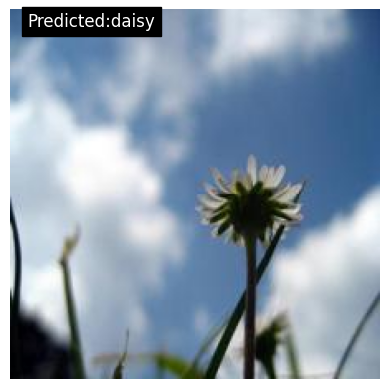

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Display the image with the predicted class name
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10, 10, f'Predicted:{predicted_class_name}', fontsize=12, color='white', backgroundcolor='black')
plt.show()